# Facade visibility × motorized traffic — daily-flow spatial join

Goal:
- Aggregate motorized traffic flows to a **daily value per edge**
- Spatially join edges with **facade visibility polygons**
- Sum intersecting flows per facade as a **proxy for views**

⚠️ Assumptions you must validate:
- `flow` represents an **hourly count** → daily aggregation = `sum`
- Edge–facade attribution via **intersects** is acceptable (can overcount)


In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

FACADES_PATH = "/Users/fadricampell/Documents/HSLU/Modules/DWDL/DWDL/AWS/containers/local_bucket/gold/facades/V2_facade_visibility.parquet"
FLOWS_PATH   = "/Users/fadricampell/Documents/HSLU/Modules/DWDL/DWDL/AWS/containers/local_bucket/gold/motorized_traffic/2025_new/V2_motorized_traffic_complete_full.parquet"

pd.set_option("display.max_columns", 200)

print(FACADES_PATH)
print(FLOWS_PATH)


/Users/fadricampell/Documents/HSLU/Modules/DWDL/DWDL/AWS/containers/local_bucket/gold/facades/V2_facade_visibility.parquet
/Users/fadricampell/Documents/HSLU/Modules/DWDL/DWDL/AWS/containers/local_bucket/gold/motorized_traffic/2025_new/V2_motorized_traffic_complete_full.parquet


In [2]:
fac = gpd.read_parquet(FACADES_PATH)
flows = gpd.read_parquet(FLOWS_PATH)

print("facades:", fac.shape)
print("flows  :", flows.shape)

display(fac.head())
display(flows.head())


facades: (415977, 6)
flows  : (252791, 12)


,objectid,bezeichnung,GWR_EGID,geometry,x_lon_center,y_lat_centre
0,11051568,Kreis 6,302017889,"POLYGON ((2682455.540 1254039.253, 2682451.146...",8.531492,47.431794
1,11051569,Kreis 6,302017889,"POLYGON ((2682451.146 1254040.298, 2682452.605...",8.531256,47.432076
2,11051570,Kreis 6,302017889,"POLYGON ((2682452.605 1254046.429, 2682456.998...",8.531661,47.432248
3,11051571,Kreis 6,302017889,"POLYGON ((2682456.998 1254045.384, 2682455.540...",8.531897,47.431966
4,11051572,Kreis 6,302017781,"POLYGON ((2682246.767 1254030.562, 2682290.315...",8.529187,47.432057


,edge_id,u,v,key,hour,total_flow,n_sources,name,length,bearing,geometry,flow_norm
0,9896,5254058386,34403221,0,0,2480.135139,57,Seestrasse,5.529,240.1,"LINESTRING (2682886.139 1244214.159, 2682881.3...",0.404751
1,1751,34403221,5254058386,0,0,1919.467696,63,Seestrasse,5.529,60.1,"LINESTRING (2682881.372 1244211.334, 2682886.1...",0.313252
2,1749,34403221,74926632,0,0,3491.011618,72,Seestrasse,24.641,147.4,"LINESTRING (2682881.372 1244211.334, 2682894.9...",0.569723
3,1750,34403221,262971442,0,0,1696.179462,56,Seestrasse,28.739,280.6,"LINESTRING (2682881.372 1244211.334, 2682878.3...",0.276812
4,6209,262971442,34403221,0,0,2638.835770,66,Seestrasse,28.739,100.6,"LINESTRING (2682854.364 1244215.983, 2682867.9...",0.430651


In [3]:
assert "geometry" in fac.columns
assert "geometry" in flows.columns
assert "hour" in flows.columns

# Flow value column
flow_value_col = None
for c in ["flow", "traffic", "count", "volume", "flow_norm"]:
    if c in flows.columns:
        flow_value_col = c
        break
if flow_value_col is None:
    raise ValueError("No flow value column found")

print("Using flow column:", flow_value_col)

# Edge ID
edge_id_col = None
for c in ["edge_id", "id", "edgeid", "u_v_key"]:
    if c in flows.columns:
        edge_id_col = c
        break
if edge_id_col is None:
    raise ValueError("No edge id column found")

print("Using edge id:", edge_id_col)

# Facade ID
facade_id_col = None
for c in ["facade_id", "id", "fid", "objectid"]:
    if c in fac.columns:
        facade_id_col = c
        break

if facade_id_col is None:
    fac = fac.reset_index(drop=True)
    fac["facade_id"] = np.arange(len(fac))
    facade_id_col = "facade_id"
    print("Created facade_id")

print("Using facade id:", facade_id_col)


Using flow column: flow_norm
Using edge id: edge_id
Using facade id: objectid


In [4]:
print("facades CRS:", fac.crs)
print("flows CRS  :", flows.crs)

if fac.crs is None:
    fac = fac.set_crs("EPSG:4326")
    print("WARNING: assumed EPSG:4326 for facades")

if flows.crs is None:
    flows = flows.set_crs("EPSG:4326")
    print("WARNING: assumed EPSG:4326 for flows")

# Use Swiss projected CRS for spatial ops
TARGET_CRS = "EPSG:2056"

fac_p = fac.to_crs(TARGET_CRS)
flows_p = flows.to_crs(TARGET_CRS)


facades CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "ProjectedCRS", "name": "CH1903+ / LV95", "base_crs": {"name": "CH1903+", "datum": {"type": "GeodeticReferenceFrame", "name": "CH1903+", "ellipsoid": {"name": "Bessel 1841", "semi_major_axis": 6377397.155, "inverse_flattening": 299.1528128}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "id": {"authority": "EPSG", "code": 4150}}, "conversion": {"name": "Swiss Oblique Mercator 1995", "method": {"name": "Hotine Oblique Mercator (variant B)", "id": {"authority": "EPSG", "code": 9815}}, "parameters": [{"name": "Latitude of projection centre", "value": 46.9524055555556, "unit": "degree", "id": {"authority": "EPSG", "code": 8811}}, {"name": "Longitude of projection centre", "value": 7.43958333333333, "unit":

In [5]:
# ⚠️ Change to 'mean' if flow is already normalized per day
agg_fun = "sum"

flows_daily = (
    flows_p[[edge_id_col, "hour", flow_value_col, "geometry"]]
    .groupby(edge_id_col, as_index=False)
    .agg(
        flow_daily=(flow_value_col, agg_fun),
        geometry=("geometry", "first")
    )
)

flows_daily = gpd.GeoDataFrame(
    flows_daily,
    geometry="geometry",
    crs=TARGET_CRS
)

print("daily flows:", flows_daily.shape)
display(flows_daily.head())


daily flows: (10533, 3)


,edge_id,flow_daily,geometry
0,1,0.078704,"LINESTRING (2678998.154 1249895.168, 2679222.0..."
1,2,0.847143,"LINESTRING (2680776.828 1248799.964, 2680771.3..."
2,3,0.801629,"LINESTRING (2680776.828 1248799.964, 2680759.2..."
3,4,0.568227,"LINESTRING (2680776.828 1248799.964, 2680782.8..."
4,5,0.646963,"LINESTRING (2680776.828 1248799.964, 2680789.5..."


In [6]:
joined = gpd.sjoin(
    flows_daily[[edge_id_col, "flow_daily", "geometry"]],
    fac_p[[facade_id_col, "geometry"]],
    how="inner",
    predicate="intersects"
)

print("joined rows:", joined.shape)
display(joined.head())


joined rows: (807428, 5)


,edge_id,flow_daily,geometry,index_right,objectid
0,1,0.078704,"LINESTRING (2678998.154 1249895.168, 2679222.0...",255014,13352025
0,1,0.078704,"LINESTRING (2678998.154 1249895.168, 2679222.0...",255015,13352026
0,1,0.078704,"LINESTRING (2678998.154 1249895.168, 2679222.0...",255047,13352058
0,1,0.078704,"LINESTRING (2678998.154 1249895.168, 2679222.0...",255045,13352056
0,1,0.078704,"LINESTRING (2678998.154 1249895.168, 2679222.0...",255040,13352051


In [7]:
views = (
    joined
    .groupby(facade_id_col, as_index=False)
    .agg(
        views=("flow_daily", "sum"),
        n_edges=(edge_id_col, "nunique")
    )
)

display(views.sort_values("views", ascending=False).head(10))


,objectid,views,n_edges
177752,13342047,319.795328,18
177519,13341809,296.722703,16
107662,13234558,293.143395,15
82310,13194971,287.767533,16
82308,13194969,287.767533,16
119352,13254212,266.634050,14
82296,13194957,266.135239,15
82298,13194959,266.135239,15
279410,13631100,264.983745,16
268946,13613595,264.954595,16


In [8]:
fac_views = fac_p.merge(views, on=facade_id_col, how="left")

fac_views["views"] = fac_views["views"].fillna(0)
fac_views["n_edges"] = fac_views["n_edges"].fillna(0).astype(int)

print("facades with views:", fac_views.shape)


facades with views: (415977, 8)


In [10]:
OUT_GPKG = "/Users/fadricampell/Documents/HSLU/Modules/DWDL/Documentation/facade_views_motorized_daily.gpkg"
LAYER_NAME = "facade_views_motorized_daily"

fac_views.to_file(
    OUT_GPKG,
    layer=LAYER_NAME,
    driver="GPKG"
)

print(f"Wrote GeoPackage: {OUT_GPKG} (layer: {LAYER_NAME})")


Wrote GeoPackage: /Users/fadricampell/Documents/HSLU/Modules/DWDL/Documentation/facade_views_motorized_daily.gpkg (layer: facade_views_motorized_daily)


KeyboardInterrupt: 

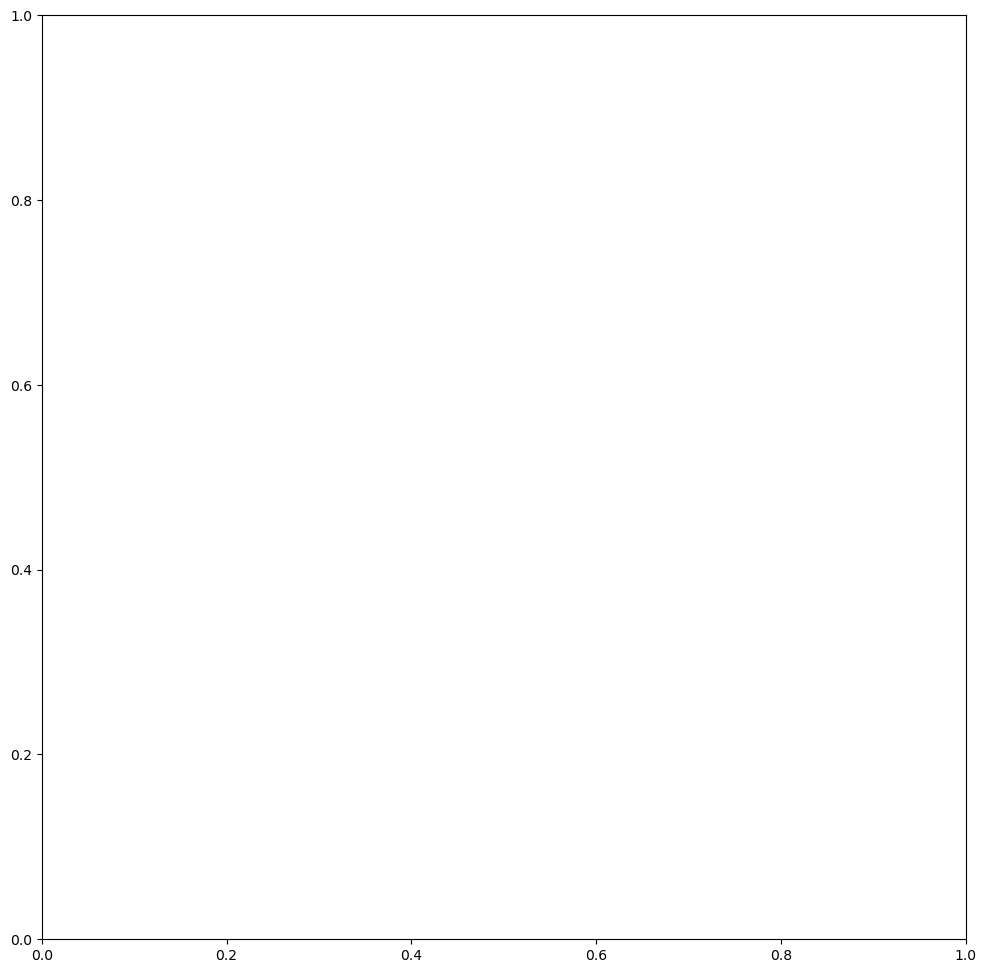

In [9]:
clip_pct = 99  # avoids extreme outliers killing the color scale

vals = fac_views["views"].to_numpy()
vmax = np.percentile(vals, clip_pct)

fig, ax = plt.subplots(figsize=(12, 12))

fac_views.plot(
    ax=ax,
    column="views",
    cmap="plasma",
    legend=True,
    vmin=0,
    vmax=vmax,
    linewidth=0.2,
    edgecolor="none"
)

flows_daily.plot(
    ax=ax,
    linewidth=0.2,
    alpha=0.15
)

ax.set_title("Facade visibility weighted by daily motorized traffic flow")
ax.set_axis_off()
plt.show()
